# sc-GEM Analysis

In [50]:
cd /home/mscs/congfeng4/GuidedStudy/Code/SCOIT/

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT


/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [51]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

DATA = 'sc_GEM'


In [52]:
ALL_CELL_STAGES = ''

In [53]:
cell_embeddings = np.load(f'./embeddings/{DATA}/mymodel_0.npy')
gene_embeddings = np.load(f'./embeddings/{DATA}/mymodel_1.npy')
omics_embeddings = np.load(f'./embeddings/{DATA}/mymodel_2.npy')
node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
cell_stage = np.unique(pd.read_csv("data/sc_GEM/cell_stage.csv", header=None))
metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [54]:
cell_stage, len(cell_stage)

(array(['BJ', 'ES', 'IPS', 'd16T+', 'd16T-', 'd24T+', 'd24T-', 'd8'],
       dtype=object),
 8)

In [55]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['BJ_1', 'BJ_11', 'BJ_12', 'BJ_13', 'BJ_14', 'BJ_15', 'BJ_17',
       'BJ_18', 'BJ_19', 'BJ_2', 'BJ_21', 'BJ_22', 'BJ_23', 'BJ_24',
       'BJ_25', 'BJ_26', 'BJ_27', 'BJ_28', 'BJ_29', 'BJ_3', 'BJ_31',
       'BJ_32', 'BJ_34', 'BJ_35', 'BJ_37', 'BJ_4', 'BJ_40', 'BJ_41',
       'BJ_43', 'BJ_44', 'BJ_46', 'BJ_5', 'BJ_7', 'BJ_8', 'BJ_9', 'ES_1',
       'ES_10', 'ES_11', 'ES_12', 'ES_13', 'ES_14', 'ES_15', 'ES_16',
       'ES_17', 'ES_18', 'ES_19', 'ES_2', 'ES_20', 'ES_21', 'ES_22',
       'ES_24', 'ES_25', 'ES_3', 'ES_4', 'ES_5', 'ES_6', 'ES_7', 'ES_8',
       'ES_9', 'IPS_1', 'IPS_10', 'IPS_11', 'IPS_12', 'IPS_13', 'IPS_16',
       'IPS_17', 'IPS_19', 'IPS_2', 'IPS_20', 'IPS_21', 'IPS_22',
       'IPS_23', 'IPS_24', 'IPS_25', 'IPS_26', 'IPS_27', 'IPS_3',
       'IPS_31', 'IPS_32', 'IPS_34', 'IPS_35', 'IPS_36', 'IPS_37',
       'IPS_38', 'IPS_39', 'IPS_4', 'IPS_40', 'IPS_44', 'IPS_45', 'IPS_5',
       'IPS_6', 'IPS_7', 'IPS_8', 'd16T+_1', 'd16T+_10', 'd16T+_11',
       'd16T+_12', 'd

In [56]:
def find_cell_stage(cell_id):
    for stage in cell_stage:
        if stage in cell_id:
            return stage
    return '??'

cell_stage_from_id = [find_cell_stage(x) for x in cell_names]

In [57]:
cell_stage_from_id

['BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16

In [58]:
# Check the stage and name.
assert len(cell_stage_from_id) == len(cell_names)

for stage, name in zip(cell_stage_from_id, cell_names):
    assert stage in name, f'stage={stage}, name={name}'

In [59]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

61

## Cell Embeddings

Text(0, 0.5, 'UMAP_2')

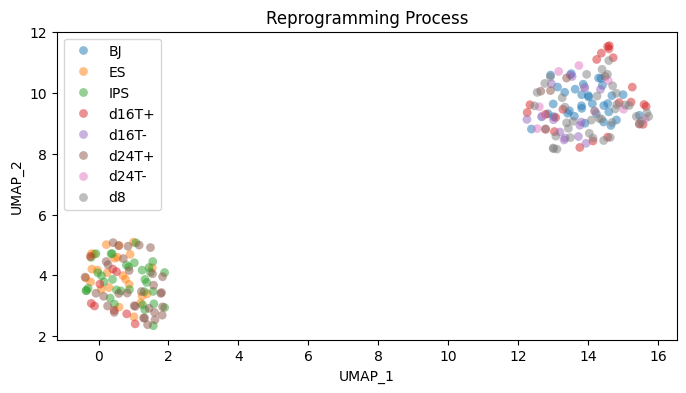

In [99]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings / cell_norms)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('Reprogramming Process')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


ES, IPS, d24T+ are in one group.

Others are in the other group.

## Heatmaps of gene embeddings

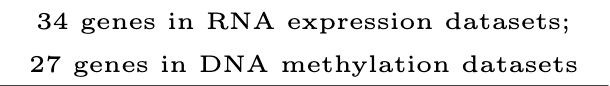

In [61]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,...,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
0,-2.307165,1.813419,1.813062,-4.741152,1.727923,6.803998,1.673647,1.939962,1.278371,0.172210,...,0.873919,0.576553,-1.492875,-0.042513,0.234944,-0.319611,0.733631,0.074568,0.518209,1.121228
1,-0.367974,-0.910620,-0.789485,0.193308,-1.588488,-14.885326,0.094215,1.048935,-0.343531,1.041057,...,-0.480600,-1.028507,0.083271,-0.388400,-0.421703,0.969218,-1.153077,-0.412276,-0.375123,-0.232961
2,0.461952,-1.916016,-0.525856,0.101079,-1.614431,5.814759,-0.679194,0.725540,-0.388151,2.249004,...,-0.527652,-0.699666,0.741376,-1.375404,-0.895716,1.503339,-0.717440,-0.497510,-0.315073,-0.405214
3,-0.186744,-0.484648,-0.645949,0.050464,-0.334977,15.669731,-0.235015,0.275101,-0.619282,0.833287,...,-0.304109,-0.227840,0.357613,-0.256403,-0.520203,0.724736,-0.316174,-0.222787,-0.339923,-0.618971
4,-1.343179,-1.278664,-0.446401,0.347292,0.093109,8.877712,-0.281638,-0.115772,-0.743577,0.974833,...,-0.716677,-1.384096,1.094936,0.683018,-0.936730,1.472407,-0.852187,0.686770,-0.030635,0.752712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-1.935613,-0.857912,-0.932442,0.390557,-1.546106,10.306317,-0.567709,-0.770656,-1.190526,1.819750,...,-0.337271,-1.089902,1.237186,-0.836239,-0.936367,1.503139,-0.870143,-0.480630,-0.348774,-0.408518
60,0.609049,-1.654693,-0.588418,0.610090,-1.780564,9.248387,-0.425378,-0.100519,-0.904606,1.944920,...,0.437853,-0.493188,2.207267,-0.569985,-0.706954,2.269061,-0.086988,0.762945,0.087509,0.296300
61,-0.026493,-0.006336,0.134605,-0.051967,-0.008176,-15.453582,-0.143842,0.435873,-0.292720,-0.803362,...,0.485356,-0.044934,0.098893,0.273695,0.039802,0.106803,0.299700,0.137677,0.419921,-0.038289
62,-0.487345,0.483566,0.178756,0.408105,0.628947,15.942610,-0.195471,-0.360674,0.415789,-0.530569,...,0.480452,0.660972,-0.405825,0.183394,0.304833,-0.487852,0.996544,0.175735,-0.202578,0.336360


In [62]:
EXPR_LIST = [
    "ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1", "IGF2", "HAND1", "TFAP2A",
    "TBX3", "FOSL1", "LUM", "TGFBR2"
]
METHY_LIST = [
    "CDH22", "KCNQ2", "NXRA8", "DPPA3", "TMEM173", "COL20A1", "TNNI3",
    "CHL1", "STON2P1", "ALDH3A1", "UNC45A", "SULT1A1", "ZNF662", "LTBR",
    "PIWIL1", "CYBRD1", "FOXD2", "HLX-AS1", "ADAM33", "NFIX", "COL23A1",
    "LY86-AS1", "NFATC1", "PLEKHH3", "TFAP2A", "EPHB3", "AK123759"
]
len(EXPR_LIST), len(METHY_LIST)

(26, 27)

## Heatmap of RNA Expression

In [63]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, EXPR_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of RNA expression on sc-GEM')

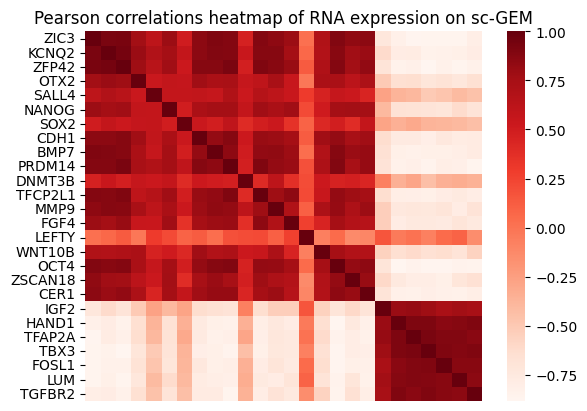

In [64]:
sns.heatmap(df_expr.corr(method='pearson'), cmap='Reds', yticklabels=EXPR_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of RNA expression on sc-GEM')

## Heatmap of DNA Methylation

In [65]:
df_methy = df_gene.loc[:, df_gene.columns.str.endswith('_methy')].rename(lambda x: x.replace('_methy', ''), axis=1)
df_methy = df_methy.loc[:, METHY_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of DNA methylation on sc-GEM')

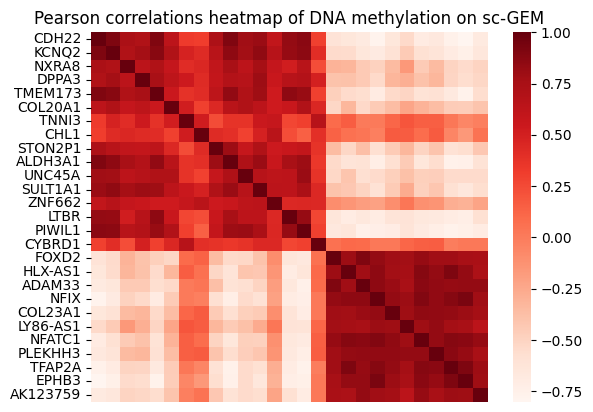

In [66]:
sns.heatmap(df_methy.corr(method='pearson'), cmap='Reds', yticklabels=METHY_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of DNA methylation on sc-GEM')

## Projection of pluripotency and somatic gene embeddings

In [67]:
pluripotency = ["ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1",]

intermedia = [
     'IGF2',
    'HAND1',
]

somatic = [
     'TFAP2A',
     'TBX3',
     'FOSL1',
     'LUM',
     'TGFBR2'
]

In [68]:
pluripotency_gene_df = df_expr.loc[:, pluripotency]
somatic_gene_df = df_expr.loc[:, somatic]

In [69]:
cell_norms = np.linalg.norm(cell_embeddings, axis=1).reshape((-1, 1))
cell_df = pd.DataFrame(cell_embeddings / cell_norms, index=cell_names)


In [70]:
np.sum(cell_df.iloc[0, :].values ** 2) # Cell embeddings normalized.

0.9999999

In [71]:
special_cell_stages = ['BJ', 'd8', 'd16', 'd24', 'IPS', 'ES']
special_cell_ids = [x for x in cell_df.index if any(stage in x for stage in special_cell_stages)]

In [72]:
special_cells_df = cell_df.loc[special_cell_ids, :].reset_index(names='cell_id')

In [73]:
def find_stage(cell_id):
    for stage in special_cell_stages:
        if stage in cell_id:
            return stage
    return '??'

special_cells_df['stage'] = special_cells_df['cell_id'].apply(find_stage)
special_cells_df = special_cells_df.drop(columns='cell_id').set_index('stage')

### Somatic projection

In [74]:
proj_somatic = (special_cells_df @ somatic_gene_df)
proj_somatic = pd.melt(proj_somatic.reset_index(), id_vars='stage')
proj_somatic


,stage,variable,value
0,BJ,TFAP2A,7.133255
1,BJ,TFAP2A,8.513267
2,BJ,TFAP2A,7.756890
3,BJ,TFAP2A,8.573587
4,BJ,TFAP2A,8.636205
...,...,...,...
1115,d8,TGFBR2,3.882472
1116,d8,TGFBR2,6.011254
1117,d8,TGFBR2,5.881213
1118,d8,TGFBR2,6.411328


Text(0, 0.5, 'Projection value')

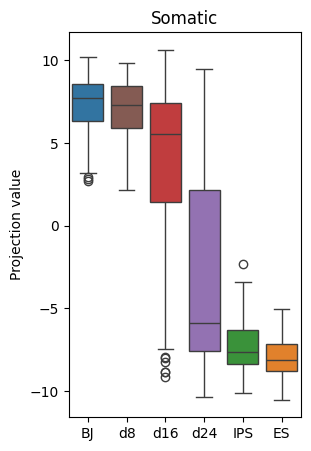

In [75]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_somatic, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Somatic')
plt.xlabel('')
plt.ylabel('Projection value')


### Pluripotency projection

In [76]:
proj_pluripotency = (special_cells_df @ pluripotency_gene_df)
proj_pluripotency = pd.melt(proj_pluripotency.reset_index(), id_vars='stage')
proj_pluripotency


,stage,variable,value
0,BJ,ZIC3,-9.685928
1,BJ,ZIC3,-9.718285
2,BJ,ZIC3,-9.828718
3,BJ,ZIC3,-10.599013
4,BJ,ZIC3,-10.330466
...,...,...,...
4251,d8,CER1,-4.938981
4252,d8,CER1,-7.574770
4253,d8,CER1,-7.720460
4254,d8,CER1,-7.844110


Text(0, 0.5, 'Projection value')

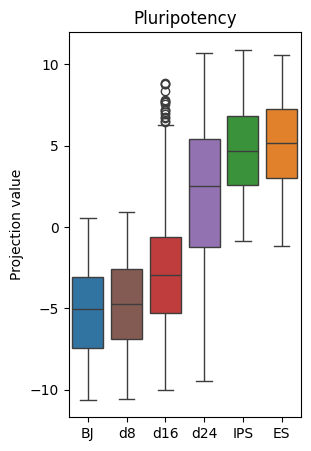

In [77]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_pluripotency, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Pluripotency')
plt.xlabel('')
plt.ylabel('Projection value')

## Cell Clustering

In [124]:
cell_embeddings.shape

(224, 64)

In [125]:
from sklearn.cluster import k_means

_, cluster, _ = k_means(UMAP(3).fit_transform(cell_embeddings / cell_norms), n_clusters=len(cell_stage))
cluster.shape

(224,)

In [79]:
cell_stage_ids = {lbl : i for i, lbl in enumerate(cell_stage)}

In [80]:
cell_stage_label = [cell_stage_ids[y] for y in cell_stage_from_id]

In [94]:
from scipy.optimize import linear_sum_assignment

k = len(cell_stage)
y = cell_stage_label
cluster_ids = cluster

def align_cluster(cluster_ids, y, k):
    # ---------- 3. build cost matrix ----------
    contingency = np.zeros((k, k), dtype=int)
    for c, gt in zip(cluster_ids, y):
        contingency[c, gt] += 1

    # cost = number of mismatches if we map cluster c -> class j
    cost_matrix = contingency.max() - contingency        # or: -contingency

    # ---------- 4. Hungarian ----------
    row_ind, col_ind = linear_sum_assignment(cost_matrix)   # same API as old linear_assignment

    # ---------- 5. remap ----------
    # build a dictionary  old_label -> new_label
    mapping = dict(zip(row_ind, col_ind))
    y_pred_aligned = np.vectorize(mapping.get)(cluster_ids)
    return y_pred_aligned


In [84]:
from sklearn.metrics import normalized_mutual_info_score # NMI
from sklearn.metrics import adjusted_rand_score # ARI
from sklearn.metrics import fowlkes_mallows_score # FMI

In [85]:
def compute_clustering_metrics(y_true, y_pred_aligned):
    return dict(
        NMI = normalized_mutual_info_score(y_true, y_pred_aligned),
        ARI = adjusted_rand_score(y_true, y_pred_aligned),
        FMI = fowlkes_mallows_score(y_true, y_pred_aligned),
    )

In [126]:
y_pred_aligned = align_cluster(cluster, cell_stage_label, len(cell_stage))

In [127]:
metrics = compute_clustering_metrics(y, y_pred_aligned)
metrics


{'NMI': 0.32781748719573617,
 'ARI': 0.15171832520999348,
 'FMI': 0.2690975038480245}

### Baselines

t-SNE, PCA, UMAP.

In [100]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

In [101]:
from hgnn.hypergraph import HyperGraphCreator
from pathlib import Path

create = HyperGraphCreator({
        'expr': './data/sc_GEM/expression_data.csv',
        'methy': './data/sc_GEM/methylation_data.csv',
    }, cell_key='Cell ID', dataname='sc_GEM', prefix=Path('./data'))

In [103]:
create.load_and_preprocess_data()
create.df

Begin to load multi omics data {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}
Load data done, time: 0.009654760360717773
Rename columns
Name: expr, Columns: Index(['ADAM33_expr', 'AFP_expr', 'AK123759_expr', 'ALDH3A1_expr', 'BMP7_expr',
       'CDH1_expr', 'CDH22_expr', 'CDX2_expr', 'CER1_expr', 'CHL1_expr',
       'COL20A1_expr', 'COL23A1_expr', 'CYBRD1_expr', 'DAZL_expr',
       'DNMT3B_expr', 'DNMT3L_expr', 'DPPA3_expr', 'EPHB3_expr', 'FGF4_expr',
       'FOSL1_expr', 'FOXD2_expr', 'HAND1_expr', 'HLX-AS1_expr', 'IGF2_expr',
       'JARID2_expr', 'KCNQ2_expr', 'LEFTY_expr', 'LTBR_expr', 'LUM_expr',
       'LY86-AS1_expr', 'MMP9_expr', 'MYC_expr', 'NANOG_expr', 'NESTIN_expr',
       'NFATC1_expr', 'NFIX_expr', 'NKX2-5_expr', 'NXRA8_expr', 'OCT4_expr',
       'OTX2_expr', 'PIWIL1_expr', 'PLEKHH3_expr', 'PRDM14_expr', 'SALL4_expr',
       'SOX2_expr', 'STON2P1_expr', 'SULT1A1_expr', 'TBX3_expr', 'TFAP2A_expr',
       'TFCP2L1_expr', 'TGFBR2_

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,...,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
Cell ID,,,,,,,,,,,,,,,,,,,,,
BJ_1,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,16.728549,...,0,0,1,1,1,1,0,0,0,0
BJ_11,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,18.601503,...,0,0,1,0,0,1,0,0,0,0
BJ_12,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,15.460834,...,0,0,1,0,0,1,1,1,0,0
BJ_13,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,18.178236,...,0,0,1,0,0,1,0,0,0,0
BJ_14,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,17.713610,...,0,0,1,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
d8_46,0.0,0.0,18.865629,0.0,0.0,0.0,15.397756,19.233267,0.0,0.000000,...,0,0,1,0,0,1,0,0,0,0
d8_5,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,16.115367,...,0,0,1,0,0,1,0,0,1,0
d8_7,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,1,0,1,1,0,1,0,0,0,0


In [106]:
assert (create.df.index == cell_names).all().all()


In [107]:
features = create.df.values
features.shape

(224, 61)

In [ ]:
baselines = {
    'TSNE' : TSNE,
    'PCA': PCA,
    'UMAP': UMAP,
}

baseline_metrics = {}

for name, method in baselines.items():
    print(name)
    x = method(n_components=3).fit_transform(features)
    x_norm = np.linalg.norm(x, axis=1).reshape((-1, 1))
    x = x / x_norm
    _, c, _ = k_means(x, k)
    c_aligned = align_cluster(c, cell_stage_label, k)
    baseline_metrics[name] = compute_clustering_metrics(cell_stage_label, c)
    print(name, baseline_metrics)


TSNE
TSNE {'TSNE': {'NMI': 0.6260501619497923, 'ARI': 0.4857836670650446, 'FMI': 0.5571747352474542}}
PCA
PCA {'TSNE': {'NMI': 0.6260501619497923, 'ARI': 0.4857836670650446, 'FMI': 0.5571747352474542}, 'PCA': {'NMI': 0.6090001553437127, 'ARI': 0.45452586011491264, 'FMI': 0.5387090270006615}}
UMAP
UMAP {'TSNE': {'NMI': 0.6260501619497923, 'ARI': 0.4857836670650446, 'FMI': 0.5571747352474542}, 'PCA': {'NMI': 0.6090001553437127, 'ARI': 0.45452586011491264, 'FMI': 0.5387090270006615}, 'UMAP': {'NMI': 0.6216001773965, 'ARI': 0.4602445784424372, 'FMI': 0.5409318576135993}}


In [116]:
baseline_metrics

{'TSNE': {'NMI': 0.6260501619497923,
  'ARI': 0.4857836670650446,
  'FMI': 0.5571747352474542},
 'PCA': {'NMI': 0.6090001553437127,
  'ARI': 0.45452586011491264,
  'FMI': 0.5387090270006615},
 'UMAP': {'NMI': 0.6216001773965,
  'ARI': 0.4602445784424372,
  'FMI': 0.5409318576135993}}

Text(0, 0.5, 'UMAP_2')

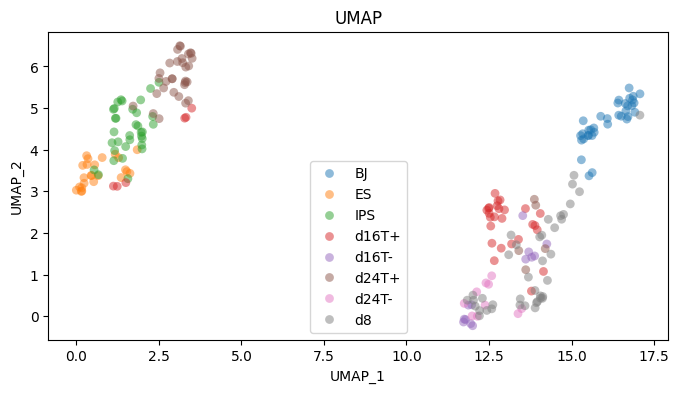

In [119]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('UMAP')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


Text(0, 0.5, 'TSNE_2')

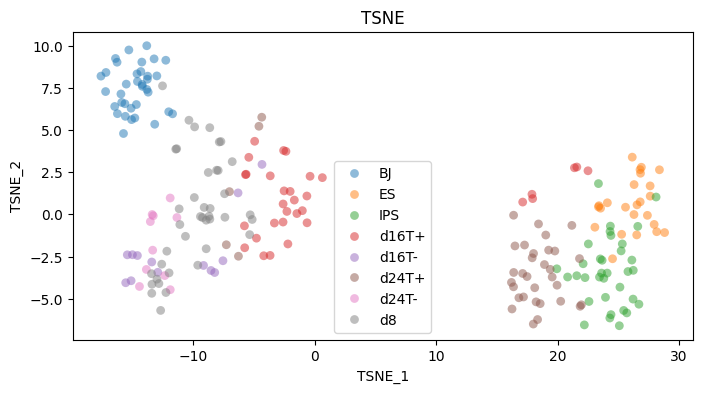

In [118]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = TSNE(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('TSNE')
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")
